In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

In [56]:
# Import flows from csv files
countries = ["IT", "PO", "CH", "FR"]
filenames = [f"{country}_net_flow_2024.csv" for country in countries]
dfs = [pd.read_csv(filename, parse_dates=["timestamp"]) for filename in filenames]
# Combine into a single DataFrame with columns for each country
combined_df = pd.DataFrame({"timestamp": dfs[0]["timestamp"]})
for country, df in zip(countries, dfs):
    combined_df[country] = df["flow_mw"]

print(combined_df.head())

                  timestamp      IT      PO      CH       FR
0 2023-01-01 00:00:00+00:00 -3116.0  1082.0 -8430.0   5674.0
1 2023-01-01 00:15:00+00:00 -3036.0  1397.0  1116.0   6973.0
2 2023-01-01 00:30:00+00:00 -2822.0  1592.0   301.0   8730.0
3 2023-01-01 00:45:00+00:00 -3235.0  1779.0   417.0  26949.0
4 2023-01-01 01:00:00+00:00 -3121.0  1417.0 -8187.0  45428.0


In [57]:
# Compute standard deviation of flows for each country
for country in countries:
    avg_flow = combined_df[country].mean()
    std_dev = combined_df[country].std()
    display(f"{country} flow: {avg_flow:.2f} MW ± {std_dev:.2f} MW")

'IT flow: -5224.92 MW ± 1686.12 MW'

'PO flow: -447.19 MW ± 1152.28 MW'

'CH flow: -680.94 MW ± 4091.03 MW'

'FR flow: 8674.00 MW ± 13768.94 MW'

In [58]:
# Compute the average for each country
for country in countries:
    avg_flow = combined_df[country].median()
    # IQR
    q75, q25 = np.percentile(combined_df[country], [75 , 25])
    iqr = q75 - q25
    display(f"{country} median flow: {avg_flow:.2f} MW ({q25:.2f} ~ {q75:.2f}) IQR: {iqr:.2f} MW")

'IT median flow: -5331.00 MW (-6354.25 ~ -4230.75) IQR: 2123.50 MW'

'PO median flow: -342.50 MW (-1220.25 ~ 161.00) IQR: 1381.25 MW'

'CH median flow: 432.50 MW (-1202.25 ~ 1721.25) IQR: 2923.50 MW'

'FR median flow: 7190.00 MW (-633.00 ~ 16345.50) IQR: 16978.50 MW'

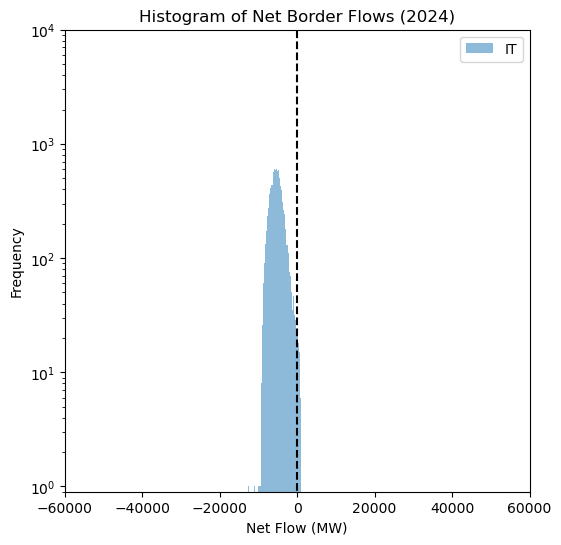

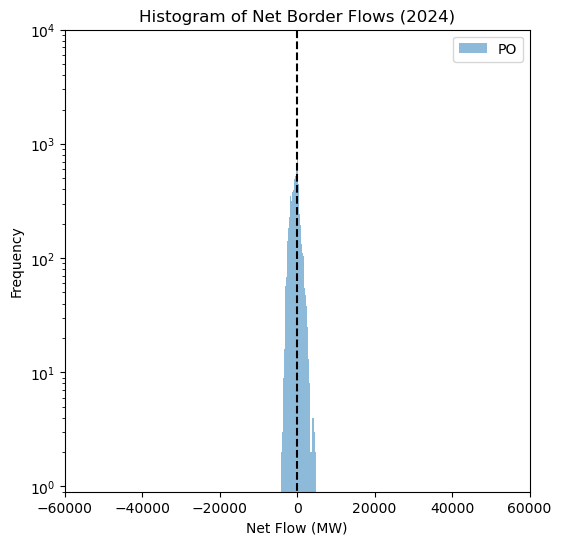

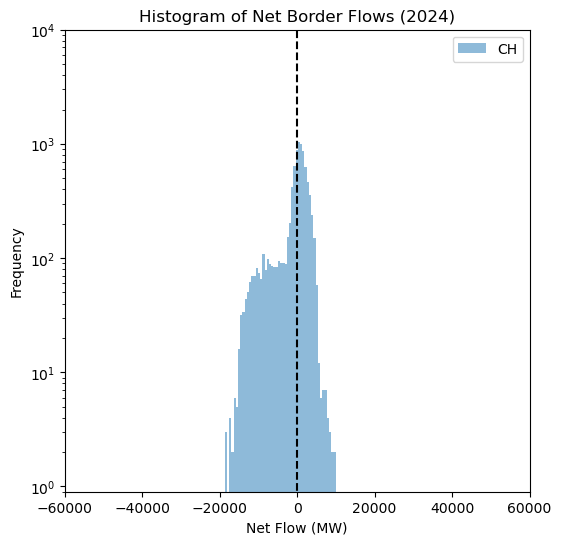

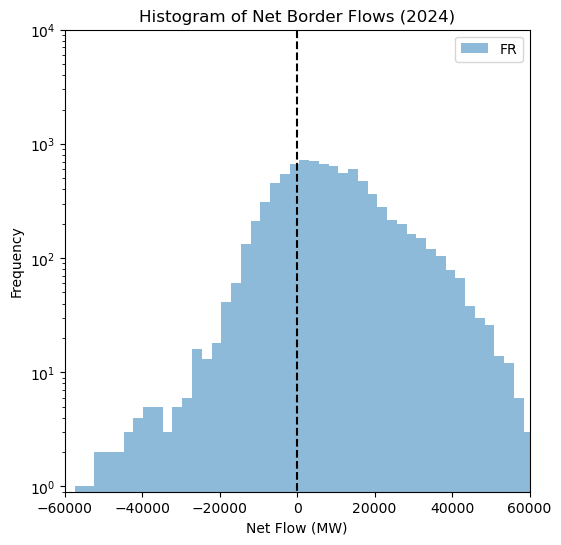

In [59]:
for country in countries:
    plt.figure(figsize=(6, 6))
    plt.hist(combined_df[country], bins=50, alpha=0.5, label=country)
    plt.xlabel("Net Flow (MW)")
    plt.ylabel("Frequency")
    plt.ylim(0.9, 1e4)
    plt.xlim(-6e4, 6e4)
    plt.title("Histogram of Net Border Flows (2024)")
    plt.yscale('log')
    plt.legend()
    plt.vlines(0, 0, 1e4, colors='k', linestyles='dashed')
    plt.show()

In [60]:
# For each country sum all positives and all negatives
for country in countries:
    # Read ../Total Loads/country.csv to get total load
    load_df = pd.read_csv(f"../Total Loads/{country}.csv")
    # Get the last column (total load)
    total_load = load_df.iloc[:, -1]
    total_load_sum = total_load.sum()/1e3
    avg_total_load = total_load.mean()/1e3
    std_total_load = total_load.std()/1e3
    
    export_total = abs(combined_df[country][combined_df[country]>0].sum()/1e3)
    hours_export = len(combined_df[country][combined_df[country]>0])
    
    import_total = abs(combined_df[country][combined_df[country]<0].sum()/1e3)
    hours_import = len(combined_df[country][combined_df[country]<0])
    
    net_flow = export_total - import_total
    
    avg_cross_border_flow = abs(combined_df[country]).mean()/1e3
    std_cross_border_flow = abs(combined_df[country]).std()/1e3

    avg_import = abs(combined_df[country][combined_df[country]<0]).mean()/1e3
    std_import = abs(combined_df[country][combined_df[country]<0]).std()/1e3
    avg_export = abs(combined_df[country][combined_df[country]>0]).mean()/1e3
    std_export = abs(combined_df[country][combined_df[country]>0]).std()/1e3

    hours_zero = len(combined_df[country][combined_df[country]==0])
    
    display(Math(rf"{country}"))
    display(Math(rf"\text{{Average Load}}:\ {{P}}_{{\text{{total}}}} = {avg_total_load:.2f}\ \pm {std_total_load:.2f}\ \mathrm{{GW}}"))
    display(Math(rf"\text{{Load Spread}}: \frac{{\sigma}}{{\mu}} \% = {std_total_load*100/avg_total_load:.2f}\ \mathrm{{\%}}"))
    
    display(Math(rf"\text{{Average Cross-Border Flow}}:\ {{P}}_{{\text{{load}}}} = {avg_cross_border_flow:.2f}\ \pm {std_cross_border_flow:.2f}\ \mathrm{{GW}}"))
    display(Math(rf"\text{{Net Flow}}:\ {net_flow:.2f}\ \mathrm{{GWh}}"))
    display(Math(rf"\text{{Net Flow Variation }}: \frac{{\sigma}}{{\mu}} \% = {abs(std_cross_border_flow)*100/abs(avg_cross_border_flow):.2f}\ \mathrm{{\%}}"))

    if net_flow >= 0:
        display(Math(rf"\text{{Export \% (Energy-wise): }} {abs(export_total)/total_load_sum *100 :.2f}\ \mathrm{{\%}}"))
        display(Math(rf"\text{{Export \% (Time wise): }} {hours_export/(8760+24)*100:.2f}\%"))
    else:
        display(Math(rf"\text{{Import \% (Energy-wise): }} {(abs(import_total/total_load_sum)*100):.2f}\ \mathrm{{\%}}"))
        display(Math(rf"\text{{Import \% (Time wise): }} {hours_import/(8760+24)*100:.2f}\%"))

    display(Math(rf"\text{{Average Import}}:\ {{P}}_{{\text{{import}}}} = {avg_import:.2f}\ \pm {std_import:.2f}\ \mathrm{{GW}}"))
    display(Math(rf"\text{{Average Export}}:\ {{P}}_{{\text{{export}}}} = {avg_export:.2f}\ \pm {std_export:.2f}\ \mathrm{{GW}}"))


    print("---")
    
    
    
    

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---
